In [2]:
import torch 
import os
import numpy as np
import torch.nn.functional as F
import pickle

from torch.utils.data import Dataset, random_split
from torch import nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [4]:
# download dataset and split train and test set

cf10_training_data = datasets.CIFAR10(root = 'data', train = True, download= True, transform= transforms.ToTensor()) 

cf10_test_data = datasets.CIFAR10(root = 'Data', train = False, download= True, transform = transforms.ToTensor())


cf100_training_data = datasets.CIFAR100(root = 'data', train = True, download= True, transform= transforms.ToTensor()) 
cf100_test_data = datasets.CIFAR100(root = 'Data', train = False, download= True, transform = transforms.ToTensor())

c:\Users\sanja\anaconda3fine\envs\torch_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [5]:
base_folder = cf100_training_data.base_folder
root = cf100_training_data.root
file_path = os.path.join(root, base_folder, 'train')

with open(file_path, 'rb')as f:
    entry =pickle.load(f, encoding = 'latin1')
    cf100_training_data.targets = entry['coarse_labels']

file_path_test = os.path.join(root, base_folder, 'test')
with open(file_path_test, 'rb') as f:
    entry_test = pickle.load(f, encoding='latin1')
    cf100_test_data.targets = entry_test['coarse_labels']

C:\Users\sanja\AppData\Local\Temp\ipykernel_9280\2307198707.py:6: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry =pickle.load(f, encoding = 'latin1')
C:\Users\sanja\AppData\Local\Temp\ipykernel_9280\2307198707.py:11: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry_test = pickle.load(f, encoding='latin1')


In [6]:
#Splitting Logic
train_size = 40000
val_size = 10000

# print(len(cf100_training_data))

cf10_train_subset, cf10_val_subset = random_split(cf10_training_data, [train_size,val_size])
#cf100_val_data = random_split(cf100_training_data, [len(cf100_training_data)*0.8, len(cf100_training_data)*0.2])

In [7]:
print(1)
training_loader = torch.utils.data.DataLoader(cf10_train_subset, batch_size=32, shuffle=True)
validation_loader = torch.utils.data.DataLoader(cf10_val_subset, batch_size=32, shuffle=False)
#testing_loader = torch.utils.data.DataLoader(cf10_test_data, batch_size=32, shuffle=False)

1


In [8]:
class LesNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)

        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, (2,2))
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, (2,2))
        X = X.flatten(1)

        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X
        
model_1 = LesNet().to(device)

In [9]:
# model 2

class Model2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)

        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        #add dropuot 
        #self.dropout = nn.Dropout2d(p = 0.3) # 30% chance to be 0

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu') #different relu

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, (2,2))
        X = F.dropout2d(X, p = 0.3)  #add dropuot 

        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, (2,2))
        X = F.dropout2d(X, p = 0.3)  #add dropuot 
        
        X = X.flatten(1)

        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

model_2 = Model2().to(device)

In [10]:
# model 3

class Model3(nn.Module): #Batch Normalization
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)
        self.bn2 = nn.BatchNorm2d(16)
        

        self.fc1 = nn.Linear(5*5*16, 120)
        self.bn3 = nn.BatchNorm1d(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

      

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu') #different relu

    def forward(self, X):
        X = F.relu(self.bn1(self.conv1(X)))
        X = F.max_pool2d(X, (2,2))
        

        X = F.relu(self.bn2(self.conv2(X)))
        X = F.max_pool2d(X, (2,2))
       

        X = X.flatten(1)

        X = F.relu(self.bn3(self.fc1(X)))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

model_3 = Model3().to(device)

In [11]:
#Train for each epoch
def train_one_epoch(model, loader,optimizer, criterion):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for inputs, label in loader:
        if torch.cuda.is_available():
                inputs, label = inputs.cuda(), label.cuda()
                model.cuda()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += label.size(0)
        correct += predicted.eq(label).sum().item()

    average_loss = running_loss / len(loader)
    
    accuracy = correct/ total * 100
    return average_loss, accuracy

In [12]:
#validate each epoch
def validate(model, loader, criterion):
    model.eval() #Set model to eval mode 
    running_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, label in loader:
            if torch.cuda.is_available():
                inputs, label = inputs.cuda(), label.cuda()
                model.cuda()
            outputs = model(inputs)
            loss = criterion(outputs, label)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += label.size(0)
            correct += predicted.eq(label).sum().item()

        average_loss = running_loss / len(loader)
        accuracy = correct/ total * 100
        return average_loss, accuracy

            

In [13]:
def run_full_training_validate(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    history = {"training_loss": [], "training_accuracy": [], "validation_loss": [], "validation_accuracy": []}
    print("---Training and Validation has started---")
    for epoch in range(epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, criterion)
        print(f"Epoch {epoch+1}, Training Loss : {train_loss}, Training Accuracy: {train_accuracy}")
        val_loss, val_accuracy = validate(model, val_loader, criterion)
        print(f"Epoch {epoch+1}, Validation Loss : {val_loss}, Validation Accuracy: {val_accuracy}")

        history['training_loss'].append(train_loss)
        history['training_accuracy'].append(train_accuracy)
        history['validation_loss'].append(val_loss)
        history['validation_accuracy'].append(val_accuracy)

    print('---Training and Validation has ended---')
    return history

In [14]:
history_1 = run_full_training_validate(model_1, training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 1.6558494794845582, Training Accuracy: 39.385
Epoch 1, Validation Loss : 1.4392138662429663, Validation Accuracy: 47.18
Epoch 2, Training Loss : 1.3650976442337037, Training Accuracy: 51.207499999999996
Epoch 2, Validation Loss : 1.315178675011705, Validation Accuracy: 52.580000000000005
Epoch 3, Training Loss : 1.2418050769805908, Training Accuracy: 55.83
Epoch 3, Validation Loss : 1.2511355646502096, Validation Accuracy: 55.120000000000005
Epoch 4, Training Loss : 1.1597469848155975, Training Accuracy: 58.72500000000001
Epoch 4, Validation Loss : 1.2008208129733515, Validation Accuracy: 56.81
Epoch 5, Training Loss : 1.087619280385971, Training Accuracy: 61.44500000000001
Epoch 5, Validation Loss : 1.1691346625550487, Validation Accuracy: 58.440000000000005
Epoch 6, Training Loss : 1.0417809170246124, Training Accuracy: 63.035
Epoch 6, Validation Loss : 1.173689664552768, Validation Accuracy: 58.35
Epoch 7, Training L

In [15]:
history_2 = run_full_training_validate(model_2, training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 1.9296943552970887, Training Accuracy: 29.4325
Epoch 1, Validation Loss : 1.7865476040794446, Validation Accuracy: 34.48
Epoch 2, Training Loss : 1.7331003805160523, Training Accuracy: 36.915
Epoch 2, Validation Loss : 1.6997587379936974, Validation Accuracy: 37.69
Epoch 3, Training Loss : 1.6688211438179017, Training Accuracy: 39.5325
Epoch 3, Validation Loss : 1.6671750713080262, Validation Accuracy: 39.85
Epoch 4, Training Loss : 1.622881711101532, Training Accuracy: 41.510000000000005
Epoch 4, Validation Loss : 1.5968169015817368, Validation Accuracy: 41.81
Epoch 5, Training Loss : 1.590689627933502, Training Accuracy: 42.57
Epoch 5, Validation Loss : 1.5791140802371235, Validation Accuracy: 42.44
Epoch 6, Training Loss : 1.5667948909759521, Training Accuracy: 43.755
Epoch 6, Validation Loss : 1.5856569834029712, Validation Accuracy: 42.3
Epoch 7, Training Loss : 1.5385895883560181, Training Accuracy: 44.4475
Epoch 

In [16]:
history_3 = run_full_training_validate(model_3, training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 1.5380185795783996, Training Accuracy: 44.365
Epoch 1, Validation Loss : 1.3821751835247198, Validation Accuracy: 50.18
Epoch 2, Training Loss : 1.250425706768036, Training Accuracy: 55.412499999999994
Epoch 2, Validation Loss : 1.2282808152631448, Validation Accuracy: 56.11000000000001
Epoch 3, Training Loss : 1.128209198141098, Training Accuracy: 60.07
Epoch 3, Validation Loss : 1.1242202567978028, Validation Accuracy: 59.89
Epoch 4, Training Loss : 1.04559445104599, Training Accuracy: 62.9275
Epoch 4, Validation Loss : 1.1648482754588507, Validation Accuracy: 58.98
Epoch 5, Training Loss : 0.9795284826278686, Training Accuracy: 65.36999999999999
Epoch 5, Validation Loss : 1.1003385471840637, Validation Accuracy: 60.78
Epoch 6, Training Loss : 0.9279702343225479, Training Accuracy: 67.145
Epoch 6, Validation Loss : 1.1070154354976007, Validation Accuracy: 60.870000000000005
Epoch 7, Training Loss : 0.8828078092813492,

In [17]:
#task 4  Current choice: model3(batch normalization) 
cf100_train_subset, cf100_val_subset = random_split(cf100_training_data, [train_size,val_size])

training_loader_cf100 = torch.utils.data.DataLoader(cf100_train_subset, batch_size=32, shuffle=True)
validation_loader_cf100 = torch.utils.data.DataLoader(cf100_val_subset, batch_size=32, shuffle=False)



In [18]:
class Model3_cf100(nn.Module): #it should be cf100 bruh
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)
        self.bn2 = nn.BatchNorm2d(16)
        

        self.fc1 = nn.Linear(5*5*16, 120)
        self.bn3 = nn.BatchNorm1d(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 20)

      

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu') #different relu

    def forward(self, X):
        X = F.relu(self.bn1(self.conv1(X)))
        X = F.max_pool2d(X, (2,2))
        

        X = F.relu(self.bn2(self.conv2(X)))
        X = F.max_pool2d(X, (2,2))
       

        X = X.flatten(1)

        X = F.relu(self.bn3(self.fc1(X)))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

model_3_cf100 = Model3_cf100().to(device)

In [19]:
history_cf100_1 = run_full_training_validate(model_3_cf100, training_loader_cf100, validation_loader_cf100)

---Training and Validation has started---
Epoch 1, Training Loss : 2.442395662117004, Training Accuracy: 25.0375
Epoch 1, Validation Loss : 2.194685130835341, Validation Accuracy: 32.32
Epoch 2, Training Loss : 2.106264492607117, Training Accuracy: 34.685
Epoch 2, Validation Loss : 2.063720162303303, Validation Accuracy: 35.86
Epoch 3, Training Loss : 1.9700237550735473, Training Accuracy: 38.85
Epoch 3, Validation Loss : 2.0107378594029828, Validation Accuracy: 38.17
Epoch 4, Training Loss : 1.8752046869277954, Training Accuracy: 41.4275
Epoch 4, Validation Loss : 1.9905905205601702, Validation Accuracy: 39.36
Epoch 5, Training Loss : 1.8001963066101074, Training Accuracy: 43.895
Epoch 5, Validation Loss : 1.9558532755976668, Validation Accuracy: 40.17
Epoch 6, Training Loss : 1.741421742630005, Training Accuracy: 45.6325
Epoch 6, Validation Loss : 1.9375046784885395, Validation Accuracy: 40.81
Epoch 7, Training Loss : 1.690117847251892, Training Accuracy: 47.04
Epoch 7, Validation Lo

In [20]:
def run_full_training_validate_2(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

    history = {"training_loss": [], "training_accuracy": [], "validation_loss": [], "validation_accuracy": []}
    print("---Training and Validation has started---")
    for epoch in range(epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, criterion)
        print(f"Epoch {epoch+1}, Training Loss : {train_loss}, Training Accuracy: {train_accuracy}")
        val_loss, val_accuracy = validate(model, val_loader, criterion)
        print(f"Epoch {epoch+1}, Validation Loss : {val_loss}, Validation Accuracy: {val_accuracy}")

        history['training_loss'].append(train_loss)
        history['training_accuracy'].append(train_accuracy)
        history['validation_loss'].append(val_loss)
        history['validation_accuracy'].append(val_accuracy)

    print('---Training and Validation has ended---')
    return history

In [21]:
CIFAR10_pretrained = model_3_cf100
CIFAR10_pretrained.fc3 = nn.Linear(84, 10).to(device)
history_pretrained = run_full_training_validate_2(
    CIFAR10_pretrained, 
    training_loader,   
    validation_loader, 
    epochs=20
)

---Training and Validation has started---
Epoch 1, Training Loss : 1.4878260876655578, Training Accuracy: 45.6575
Epoch 1, Validation Loss : 1.2637450620770074, Validation Accuracy: 54.06999999999999
Epoch 2, Training Loss : 1.220568958234787, Training Accuracy: 56.165
Epoch 2, Validation Loss : 1.2051942302776983, Validation Accuracy: 57.02
Epoch 3, Training Loss : 1.1318249432086944, Training Accuracy: 59.72
Epoch 3, Validation Loss : 1.118837124052139, Validation Accuracy: 60.28
Epoch 4, Training Loss : 1.0705353347778321, Training Accuracy: 61.6725
Epoch 4, Validation Loss : 1.0957885127478895, Validation Accuracy: 60.78
Epoch 5, Training Loss : 1.0194322023391724, Training Accuracy: 63.692499999999995
Epoch 5, Validation Loss : 1.110038320286967, Validation Accuracy: 60.709999999999994
Epoch 6, Training Loss : 0.9842793725967407, Training Accuracy: 64.9125
Epoch 6, Validation Loss : 1.0677251648217345, Validation Accuracy: 61.7
Epoch 7, Training Loss : 0.9421976207733155, Training

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

In [23]:
testing_loader = torch.utils.data.DataLoader(cf10_test_data, batch_size=32, shuffle=False)

In [24]:
labels_best, preds_best = get_predictions(model_3, testing_loader)
labels_pretrained, preds_pretrained = get_predictions(CIFAR10_pretrained, testing_loader)

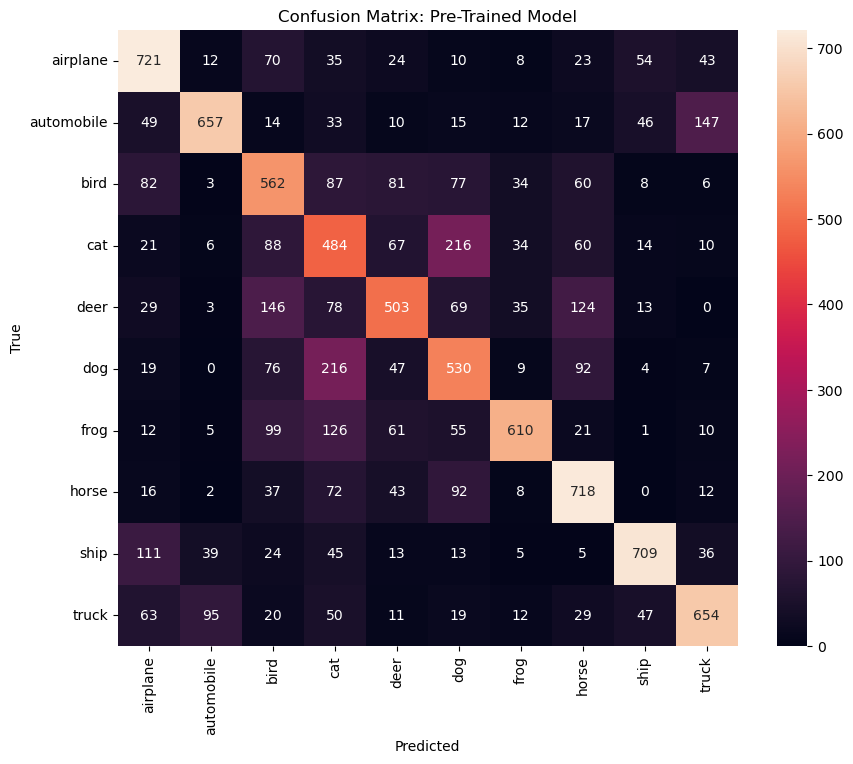

In [28]:
import seaborn as sns
cm = confusion_matrix(labels_pretrained, preds_pretrained)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=cf10_training_data.classes, yticklabels=cf10_training_data.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: Pre-Trained Model')
plt.show()

In [30]:
cr = classification_report(labels_pretrained, preds_pretrained)
print(cr)

              precision    recall  f1-score   support

           0       0.64      0.72      0.68      1000
           1       0.80      0.66      0.72      1000
           2       0.49      0.56      0.53      1000
           3       0.39      0.48      0.43      1000
           4       0.58      0.50      0.54      1000
           5       0.48      0.53      0.51      1000
           6       0.80      0.61      0.69      1000
           7       0.62      0.72      0.67      1000
           8       0.79      0.71      0.75      1000
           9       0.71      0.65      0.68      1000

    accuracy                           0.61     10000
   macro avg       0.63      0.61      0.62     10000
weighted avg       0.63      0.61      0.62     10000



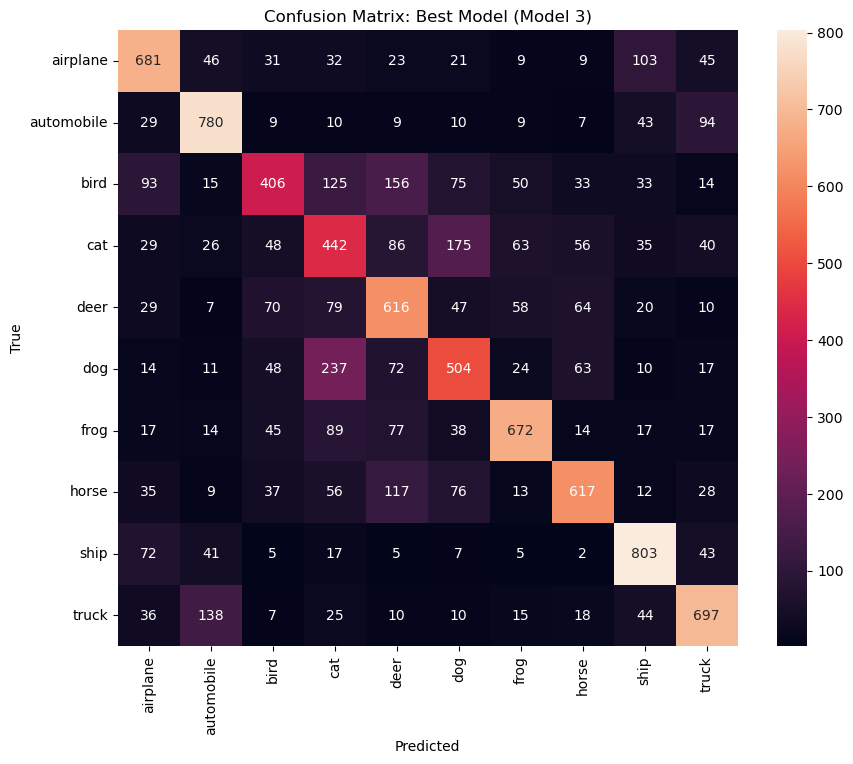

In [29]:
import seaborn as sns
cm = confusion_matrix(labels_best, preds_best)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=cf10_training_data.classes, yticklabels=cf10_training_data.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: Best Model (Model 3)')
plt.show()

In [31]:
cr = classification_report(labels_best, preds_best)
print(cr)

              precision    recall  f1-score   support

           0       0.66      0.68      0.67      1000
           1       0.72      0.78      0.75      1000
           2       0.58      0.41      0.48      1000
           3       0.40      0.44      0.42      1000
           4       0.53      0.62      0.57      1000
           5       0.52      0.50      0.51      1000
           6       0.73      0.67      0.70      1000
           7       0.70      0.62      0.66      1000
           8       0.72      0.80      0.76      1000
           9       0.69      0.70      0.70      1000

    accuracy                           0.62     10000
   macro avg       0.62      0.62      0.62     10000
weighted avg       0.62      0.62      0.62     10000



To get all the info needed

In [35]:
#Getting results for three models

def print_model_summary(name, history):

    final_train_accuracy = history['training_accuracy'][-1]
    final_validation_accuracy = history['validation_accuracy'][-1]

    best_val_accuracy = max(history['validation_accuracy'])
    best_epoch = history['validation_accuracy'].index(best_val_accuracy) + 1  
    
    print(f"--- {name}'s Summary ---")
    print(f'Final Training Accuracy: {final_train_accuracy:.2f}%')
    print(f'Final Validation Accuracy: {final_validation_accuracy:.2f}%')
    print(f"Best Validation Accuracy: {best_val_accuracy:.2f}% (at Epoch {best_epoch})")



In [36]:
print_model_summary("CIFAR10_LeNet", history_1)
print_model_summary("CIFAR10_model_1 (Dropout)", history_2)
print_model_summary("CIFAR10_model_2 (BatchNorm)", history_3)

--- CIFAR10_LeNet's Summary ---
Final Training Accuracy: 80.19%
Final Validation Accuracy: 58.46%
Best Validation Accuracy: 60.29% (at Epoch 11)
--- CIFAR10_model_1 (Dropout)'s Summary ---
Final Training Accuracy: 51.01%
Final Validation Accuracy: 47.59%
Best Validation Accuracy: 47.60% (at Epoch 16)
--- CIFAR10_model_2 (BatchNorm)'s Summary ---
Final Training Accuracy: 79.96%
Final Validation Accuracy: 62.13%
Best Validation Accuracy: 63.43% (at Epoch 11)


In [42]:
def training_history_plot(name, history):
    epochs = range(1, len(history['training_loss']) + 1)

    plt.figure(figsize=(12,5))

    # plotting loss
    
    plt.subplot(1,2,1)
    plt.plot(epochs, history['training_loss'], 'r-', label='Training Loss' )
    plt.plot(epochs, history['validation_loss'], 'b-', label='Validation Loss' )
    plt.title(f'{name}: Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # plotting accuracy

    plt.subplot(1,2,2)
    plt.plot(epochs, history['training_accuracy'], 'r-', label='Training Accuracy' )
    plt.plot(epochs, history['validation_accuracy'], 'b-', label='Validation Accuracy' )
    plt.title(f'{name}: Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()


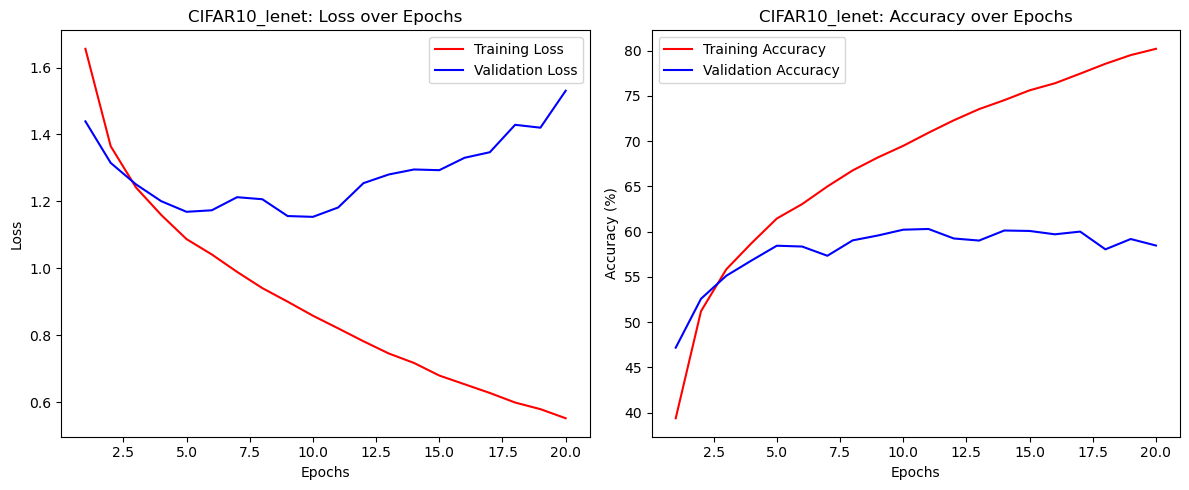

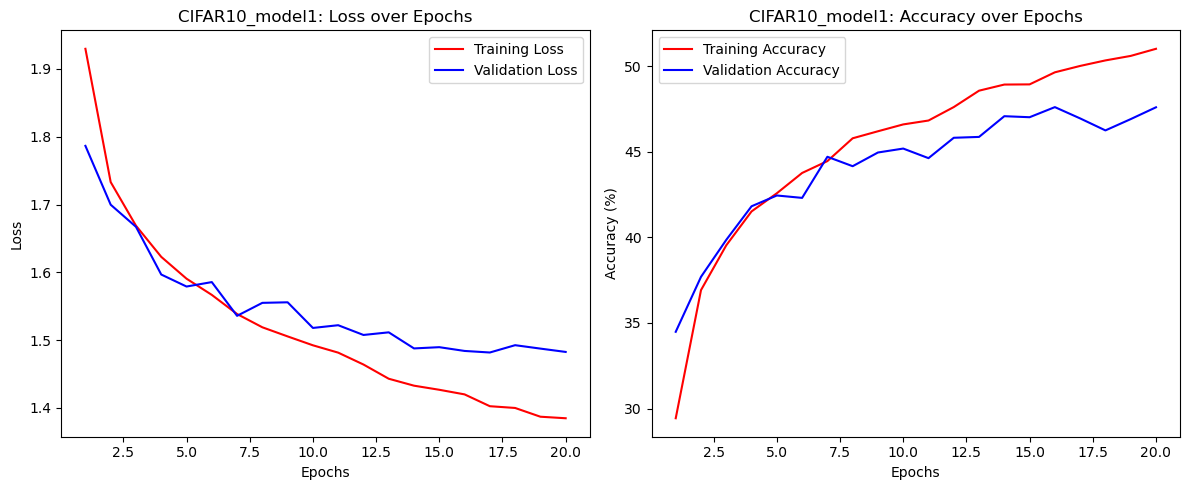

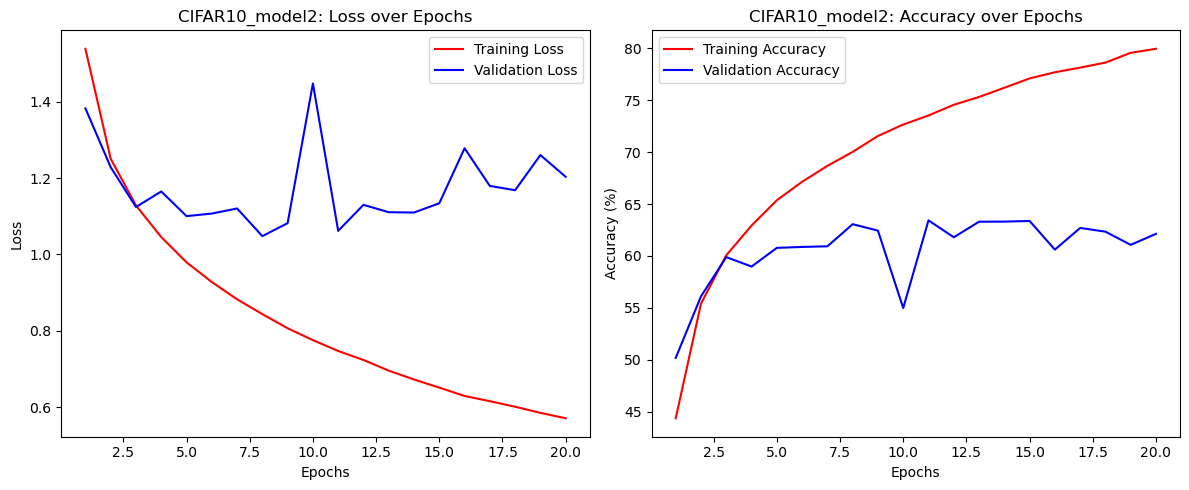

In [43]:
training_history_plot("CIFAR10_lenet", history_1)
training_history_plot("CIFAR10_model1", history_2)
training_history_plot("CIFAR10_model2", history_3)